In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv('wine.csv')

In [3]:
df1.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df1.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [5]:
df1.info

<bound method DataFrame.info of      Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0       1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1       1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2       1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3       1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4       1    13.24   2.59  2.87        21.0        118     2.80        2.69   
..    ...      ...    ...   ...         ...        ...      ...         ...   
173     3    13.71   5.65  2.45        20.5         95     1.68        0.61   
174     3    13.40   3.91  2.48        23.0        102     1.80        0.75   
175     3    13.27   4.28  2.26        20.0        120     1.59        0.69   
176     3    13.17   2.59  2.37        20.0        120     1.65        0.68   
177     3    14.13   4.10  2.74        24.5         96     2.05        0.76   

     Nonflavanoids 

In [6]:
df1.describe

<bound method NDFrame.describe of      Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0       1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1       1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2       1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3       1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4       1    13.24   2.59  2.87        21.0        118     2.80        2.69   
..    ...      ...    ...   ...         ...        ...      ...         ...   
173     3    13.71   5.65  2.45        20.5         95     1.68        0.61   
174     3    13.40   3.91  2.48        23.0        102     1.80        0.75   
175     3    13.27   4.28  2.26        20.0        120     1.59        0.69   
176     3    13.17   2.59  2.37        20.0        120     1.65        0.68   
177     3    14.13   4.10  2.74        24.5         96     2.05        0.76   

     Nonflavanoid

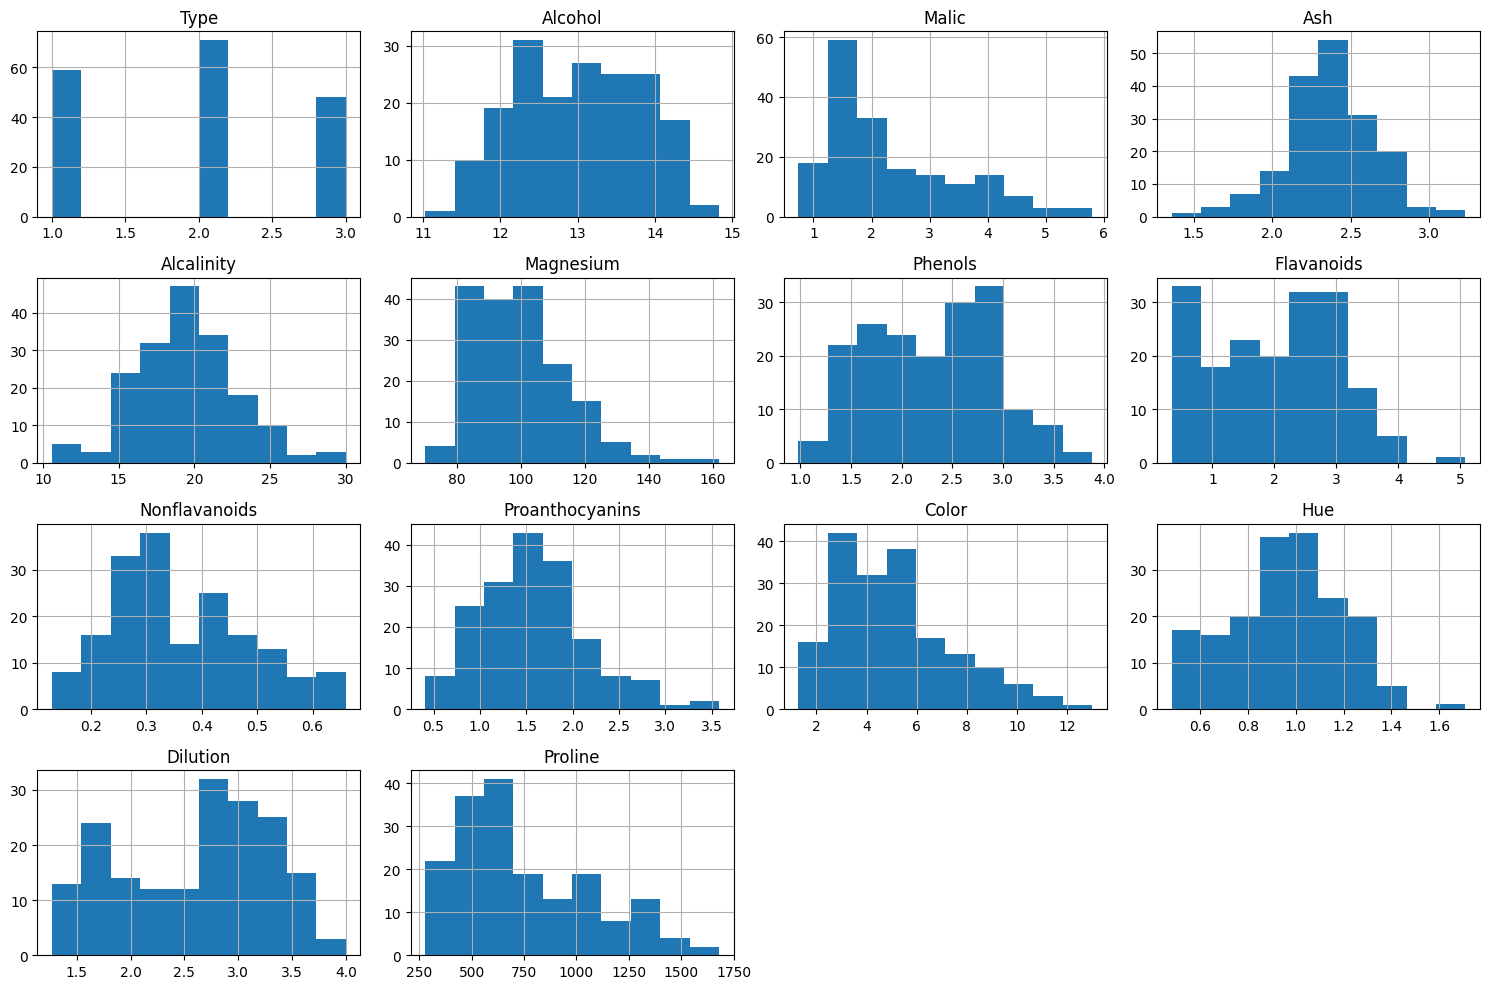

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
df1.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()


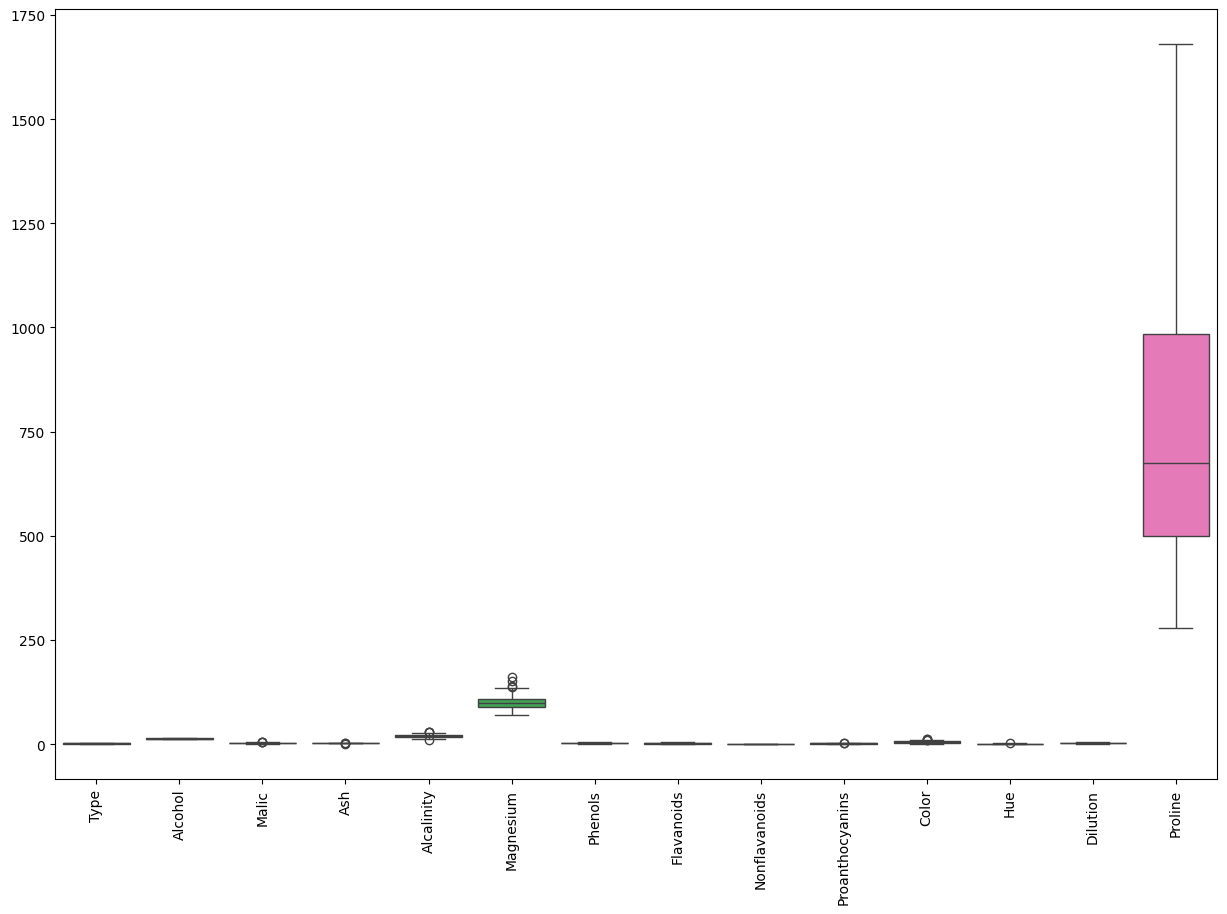

In [8]:
# Box plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df1)
plt.xticks(rotation=90)
plt.show()


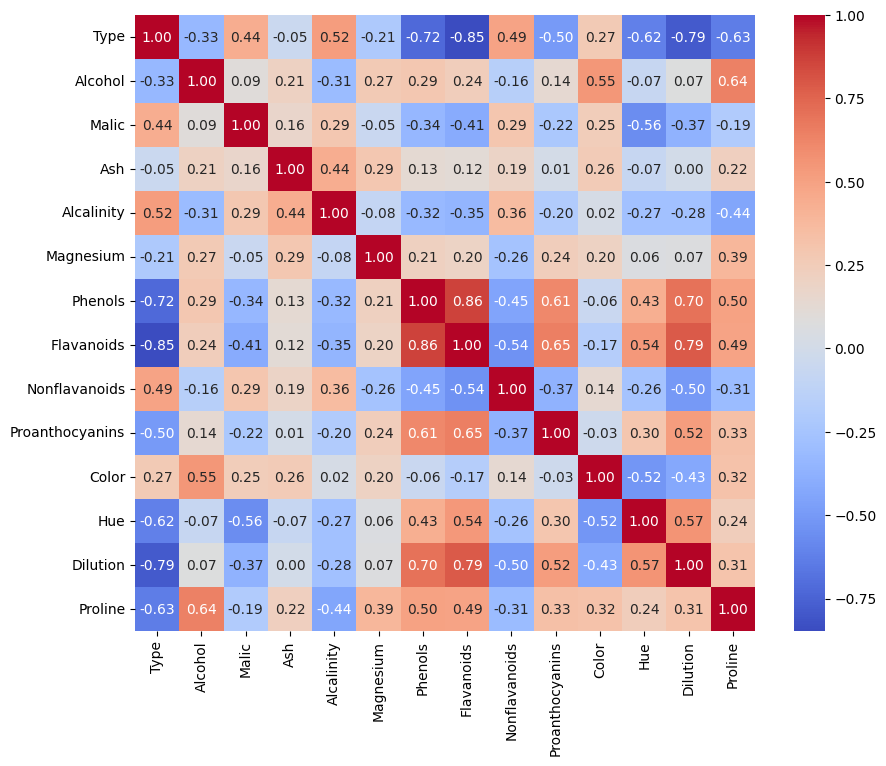

In [9]:
# Correlation matrix
corr = df1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)


In [11]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [13]:
import numpy as np

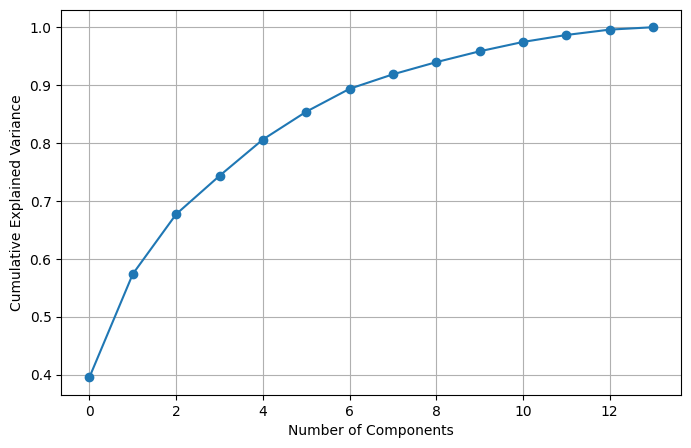

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()


In [15]:
# PCA with optimal components (example: 2)
pca = PCA(n_components=2)
X_pca_2 = pca.fit_transform(X_scaled)


In [16]:
pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df.head()


,PC1,PC2
0,-3.522934,1.453098
1,-2.528858,-0.330019
2,-2.785029,1.036936
3,-3.922588,2.768210
4,-1.407511,0.867773


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans.fit_predict(X_scaled)


C:\Users\nalla\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


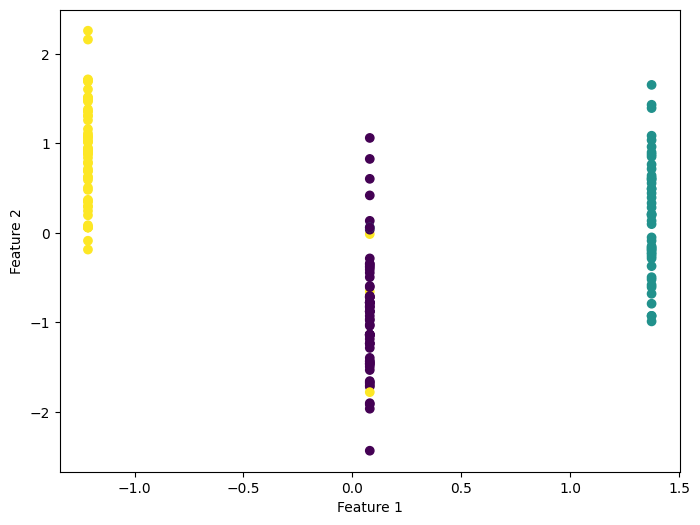

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_original)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_orig = silhouette_score(X_scaled, clusters_original)
db_orig = davies_bouldin_score(X_scaled, clusters_original)

silhouette_orig, db_orig


(0.30648398324833453, 1.315707552261773)

In [20]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca_2)


C:\Users\nalla\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


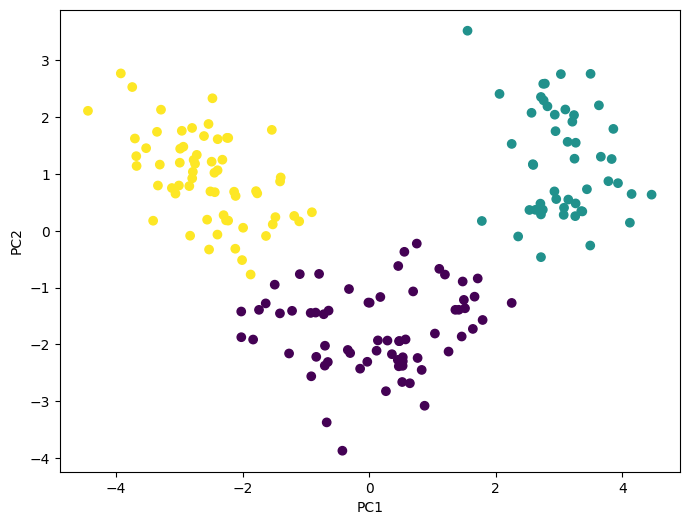

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=clusters_pca)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [22]:
silhouette_pca = silhouette_score(X_pca_2, clusters_pca)
db_pca = davies_bouldin_score(X_pca_2, clusters_pca)

silhouette_pca, db_pca


(0.6024415520362846, 0.5397078562575711)

In [23]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_orig, silhouette_pca],
    "Davies-Bouldin Index": [db_orig, db_pca]
})

comparison


,Method,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.306484,1.315708
1,PCA Data,0.602442,0.539708


## Comparison
## Before Applying PCA (Original Feature Space)

**What we see**

Points are plotted using two original features

Clusters appear as vertical bands

Separation is mostly along one axis (Feature 1)

**Analysis**

- Poor multi-dimensional representation

The Wine dataset has 13 features

Plotting only 2 original features loses most information

- Feature correlation issue

Original features are correlated

K-Means struggles because distance calculations are influenced by redundancy

- Cluster overlap

Middle cluster overlaps vertically with others

Boundaries are unclear → harder to distinguish clusters visually

- Misleading visualization

Data may look line-like or compressed

Clusters appear less compact than they truly are

**Conclusion (Before PCA):**
Clustering exists, but structure is not clearly visible due to high dimensionality and correlated features.

### After Applying PCA (PC1 vs PC2)

**What we see**

Data projected onto Principal Component 1 & 2

Three clearly separated clusters

Clusters are compact and well-spread

**Analysis**

- Maximum variance captured

PC1 and PC2 capture the most important information

Noise and redundancy removed

- Improved cluster separation

Distinct gaps between clusters

Very little overlap

- True 2D visualization

PCA transforms 13D data → meaningful 2D space

Distances now reflect actual relationships

- Better K-Means performance

Centroids are well positioned

Intra-cluster distance ↓

Inter-cluster distance ↑

**Conclusion (After PCA):**
Clusters are well-defined, interpretable, and visually separable, indicating improved clustering quality.

### Discussion

**Similarities & Differences**

PCA clusters are often more compact

PCA removes noise and correlated features

Original data preserves full information but is harder to visualize

**Impact of PCA**

Improves visualization

Can improve clustering quality

Slight information loss possible



### Conclusion

PCA significantly reduces dimensionality while preserving variance

Clustering on PCA-transformed data improves clarity and efficiency

Wine dataset naturally forms 3 distinct clusters

### Practical Implications

PCA + clustering is ideal for:

High-dimensional datasets

Feature-heavy chemical or biological data

Reduces computation and noise

### Recommendations

Use PCA before clustering when:

Features are correlated

Visualization is required

Cluster original data when:

Feature-level interpretability is critical